In [128]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme()

In [129]:
X = np.array(
    [
        [1, 4, 1.5, 3.8],
        [3, 6, 1.0, 3.1],
        [4, 7, 0.8, 3.9],
        [6, 8, 0.4, 3.4],
        [7, 9, 0.2, 2.8]
    ]
)


# w = [5, 10, -2, 0.5], b=2.0
# y = np.array([45, 60, 72, 85, 95])
y = np.array([ 45.9 ,  76.55,  92.35, 112.9 , 128.  ])

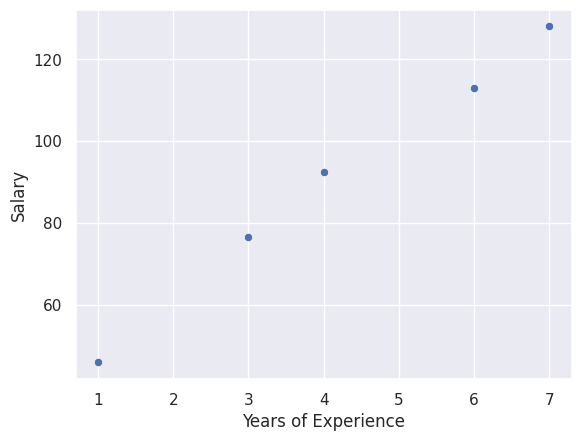

In [130]:
sns.scatterplot(x=X[:, 0:1].ravel(), y=y)
plt.xlabel("Years of Experience")
plt.ylabel("Salary")
plt.show()

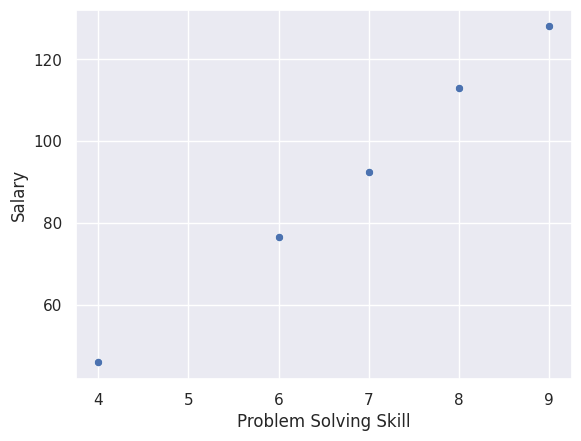

In [131]:
sns.scatterplot(x=X[:, 1:2].ravel(), y=y)
plt.xlabel("Problem Solving Skill")
plt.ylabel("Salary")
plt.show()

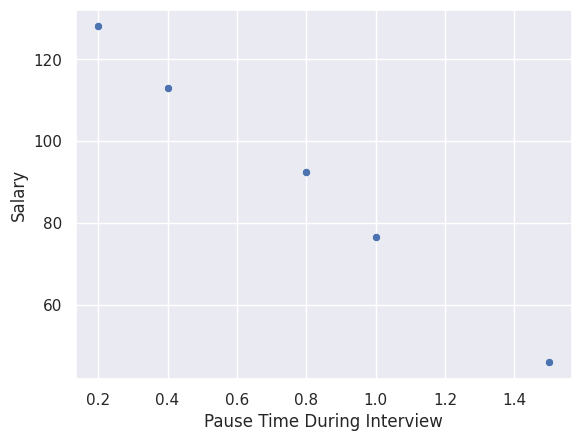

In [132]:
sns.scatterplot(x=X[:, 2:3].ravel(), y=y)
plt.xlabel("Pause Time During Interview")
plt.ylabel("Salary")
plt.show()

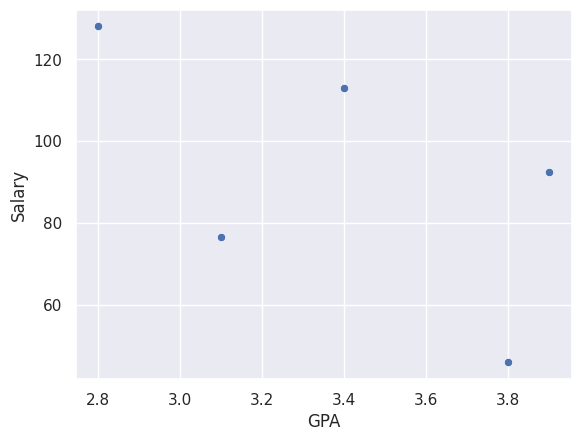

In [133]:
sns.scatterplot(x=X[:, 3:4].ravel(), y=y)
plt.xlabel("GPA")
plt.ylabel("Salary")
plt.show()

In [134]:
def make_prediction(X, W, b):
    m = X.shape[0]
    pred_list = np.zeros((m, ))


    for i in range(m):
        pred_list[i] = np.dot(W, X[i]) + b      # X[i] = feature vector, W = weight_vector. Dot Product.

    return pred_list

In [135]:
m = X.shape[0]
n = X.shape[1]

W_init = np.ones((n, ))
b_init = 1.0


make_prediction(X, W_init, b_init)

array([11.3, 14.1, 16.7, 18.8, 20. ])

In [136]:
def compute_cost(X, y, W, b):
    m = X.shape[0]
    cost = 0.0

    pred_list = make_prediction(X, W, b)

    error = pred_list - y
    error_sq = error ** 2

    cost = np.sum(error_sq) / (2*m) # 2m for convention.

    return cost

In [137]:
W_init = np.ones((n, ))
b_init = 1.0
compute_cost(X, y, W_init, b_init)

np.float64(3133.8895)

In [138]:
def calculate_gradient(X, y, W, b):
    m = X.shape[0]
    n = X.shape[1] # Column

    dj_dw = np.zeros((n, ))
    dj_db = 0.0

    for i in range(m):
        prediction = np.dot(W, X[i]) + b
        error = prediction - y[i]
        dj_db += error

        for j in range(n):
            dj_dw[j] += ( error * X[i, j] )

    return dj_dw / m , dj_db / m

In [139]:
W_init = np.ones((n, ))
b_init = 1.0
calculate_gradient(X, y, W_init, b_init)

(array([-369.03 , -553.49 ,  -46.822, -248.49 ]),
 np.float64(-74.96000000000001))

### Cost Optimization

In [140]:
# make_prediction(X, W=[5, 10, -2, 0.5], b=2)

In [141]:
def gradient_descent(X, y, w_input, b_input, max_iter, alpha=0.01):
  """Automates the tuning of w and b to minimize cost"""
  w = w_input
  b = b_input
  cost_memo = []
  iteration = []

  for i in range(max_iter):
    # 1. Calculate the gradients (the slope)
    dj_dw, dj_db = calculate_gradient(X, y, w, b)

    # 2. Update parameters by taking a small step (alpha) against the gradient

    w = w - alpha * dj_dw
    b = b - alpha * dj_db



    # 3. Track progress by saving the cost
    cost = compute_cost(X,y, w, b)
    cost_memo.append(cost)
    iteration.append(i)

    # Log the status every 100 steps
    if i % 100 == 0:
      print(f"Iteration {i}: Cost {cost:0.4f},dj_dw: {dj_dw} ,dj_db : {dj_db} w: {w}, b: {b:0.4f}")

  return w, b, cost_memo, iteration

In [142]:
W_init = np.zeros((n, ))
b_init = 0.0

w_final, b_final, cost_memo, iter_list = gradient_descent(X, y, w_input=W_init, b_input=b_init, max_iter=100000, alpha=0.01)

Iteration 0: Cost 156.1039,dj_dw: [-443.67  -668.91   -58.008 -302.83 ] ,dj_db : -91.14 w: [4.4367  6.6891  0.58008 3.0283 ], b: 0.9114
Iteration 100: Cost 0.2098,dj_dw: [-0.22813628 -0.05864     0.1660582   0.40032538] ,dj_db : 0.06331085583785949 w: [ 6.9123284   8.13950271 -0.26204608  1.85090047], b: 0.7323
Iteration 200: Cost 0.1555,dj_dw: [ 0.04414774 -0.0692271  -0.0045622   0.08929593] ,dj_db : -0.00334103833398558 w: [ 6.94596089  8.20635679 -0.30628534  1.67135256], b: 0.7166
Iteration 300: Cost 0.1422,dj_dw: [ 0.05827911 -0.06692009 -0.01369624  0.06699873] ,dj_db : -0.006766264873328964 w: [ 6.89119981  8.27458222 -0.29493507  1.59722801], b: 0.7225
Iteration 400: Cost 0.1302,dj_dw: [ 0.0567367  -0.06396552 -0.01302088  0.06252647] ,dj_db : -0.006358586708975622 w: [ 6.83349662  8.34000876 -0.2814525   1.5327401 ], b: 0.7291
Iteration 500: Cost 0.1193,dj_dw: [ 0.05434933 -0.06110576 -0.01181208  0.05929749] ,dj_db : -0.005749899275774339 w: [ 6.77796238  8.40251909 -0.26903

In [143]:
print(w_final)
print(b_final)


# w = [5, 10, -2, 0.5], b=2.0

[ 5.11132133 10.0817728  -1.17045734  0.49129992]
0.3588521020632279


In [145]:
X_test = [2, 10, 1.5, 3.8]
prediction = w_final[0] * X_test[0] + w_final[1] * X_test[1] + w_final[2] * X_test[2] + w_final[3] * X_test[3] + b_final
print(prediction)

111.51047644348101


# Using Scikit Learn

### Linear Regression


In [149]:
from sklearn.linear_model import LinearRegression # For Small DataSet
from sklearn.linear_model import SGDRegressor # For Massive DataSet

In [151]:
model_1 = LinearRegression()


model_1.fit(X, y)

weights, bias = model_1.coef_, model_1.intercept_
print(weights, bias)


# w = [5, 10, -2, 0.5], b=2.0. ------------->>> Accurate AF

[ 5.  10.  -2.   0.5] 2.000000000000071


### SGD Regressor

In [167]:
model_2 = SGDRegressor(penalty=None, max_iter=1000000, learning_rate='constant')

model_2.fit(X, y)

weights, bias = model_2.coef_, model_2.intercept_
print(weights, bias)

# w = [5, 10, -2, 0.5], b=2.0. ------------->>> Not Accurate THAT MUCH. :(

[ 6.76637892  8.48099879 -0.25227061  1.4111404 ] [0.74809971]
